In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

#Remove customerID as it's not useful for modeling

df =  df.drop("customerID", axis = 1)

print(f"Dataset Shape: {df.shape}")
print(f"Number of Customers: {df.shape[0]:,}")
print(f"Number of Features: {df.shape[1]}")

Dataset Shape: (7043, 20)
Number of Customers: 7,043
Number of Features: 20


In [4]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [5]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.describe()
#don't mind about senior citizen description

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [6]:
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

Missing Values:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Total Missing Values: 11


In [23]:
df_clean = df.copy()
# Handle null values
if df_clean['TotalCharges'].isnull().sum() > 0:
    # Fill with median or drop rows
    df_clean = df_clean.dropna(subset=['TotalCharges'])
    print(f"Rows after cleaning: {df_clean.shape[0]}")

Rows after cleaning: 7032


In [8]:
# Color Palettes

TELECOM_CATEGORICAL = [
    "#1E2A38",  # dark navy
    "#2EC4B6",  # teal
    "#3A86FF",  # blue
    "#FFBE0B",  # yellow
    "#E63946",  # red (churn / risk)
]

TELECOM_CONTINUOUS = [
    "#0B3C5D",
    "#1F7A8C",
    "#4FB0C6",
    "#A3D5E0",
    "#EAF6F9",
]


def set_telecom_style():
    """
    Sets the default plotting style for telecom EDA.
    - Uses a calm, continuous palette by default
    - Keeps high-contrast palette for explicit categorical plots (e.g. churn)
    """
    sns.set_theme(
        style="whitegrid",
        context="notebook",
        palette=TELECOM_CONTINUOUS,
        rc={
            "axes.titlesize": 14,
            "axes.titleweight": "bold",
            "axes.labelsize": 12,
            "figure.figsize": (8, 5),
            "grid.alpha": 0.3,
        },
    )


Churn Distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


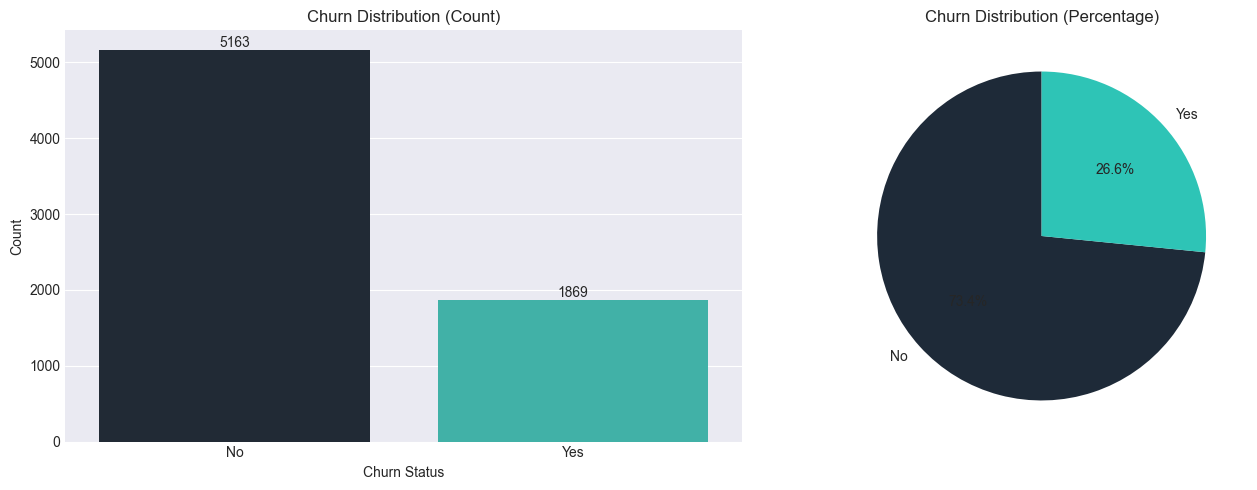

In [9]:
# BLOCK 1 — Baseline Churn Distribution
# Churn distribution
churn_counts = df_clean["Churn"].value_counts()
churn_pct = df_clean["Churn"].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(churn_counts)
print("\nPercentage:")
print(churn_pct)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot (explicit categorical palette for churn)
sns.countplot(
    data=df_clean,
    x="Churn",
    ax=axes[0],
    palette=TELECOM_CATEGORICAL
)

axes[0].set_title("Churn Distribution (Count)")
axes[0].set_xlabel("Churn Status")
axes[0].set_ylabel("Count")

for container in axes[0].containers:
    axes[0].bar_label(container)

# Pie chart (matplotlib → explicit colors required)
axes[1].pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=TELECOM_CATEGORICAL[:len(churn_counts)],
)

axes[1].set_title("Churn Distribution (Percentage)")

plt.tight_layout()
plt.show()


1️⃣ Churn Distribution (Count + Percentage)
- What your plot shows

- No churn: 5163 (~73.4%)

- Yes churn: 1869 (~26.6%)

Statistical meaning

- This is moderate class imbalance

- Not severe enough to require SMOTE by default

- But accuracy is misleading

Correct modeling implications

✅ Use:

- Stratified K-Fold

- ROC-AUC / PR-AUC

- Recall / cost-sensitive threshold tuning

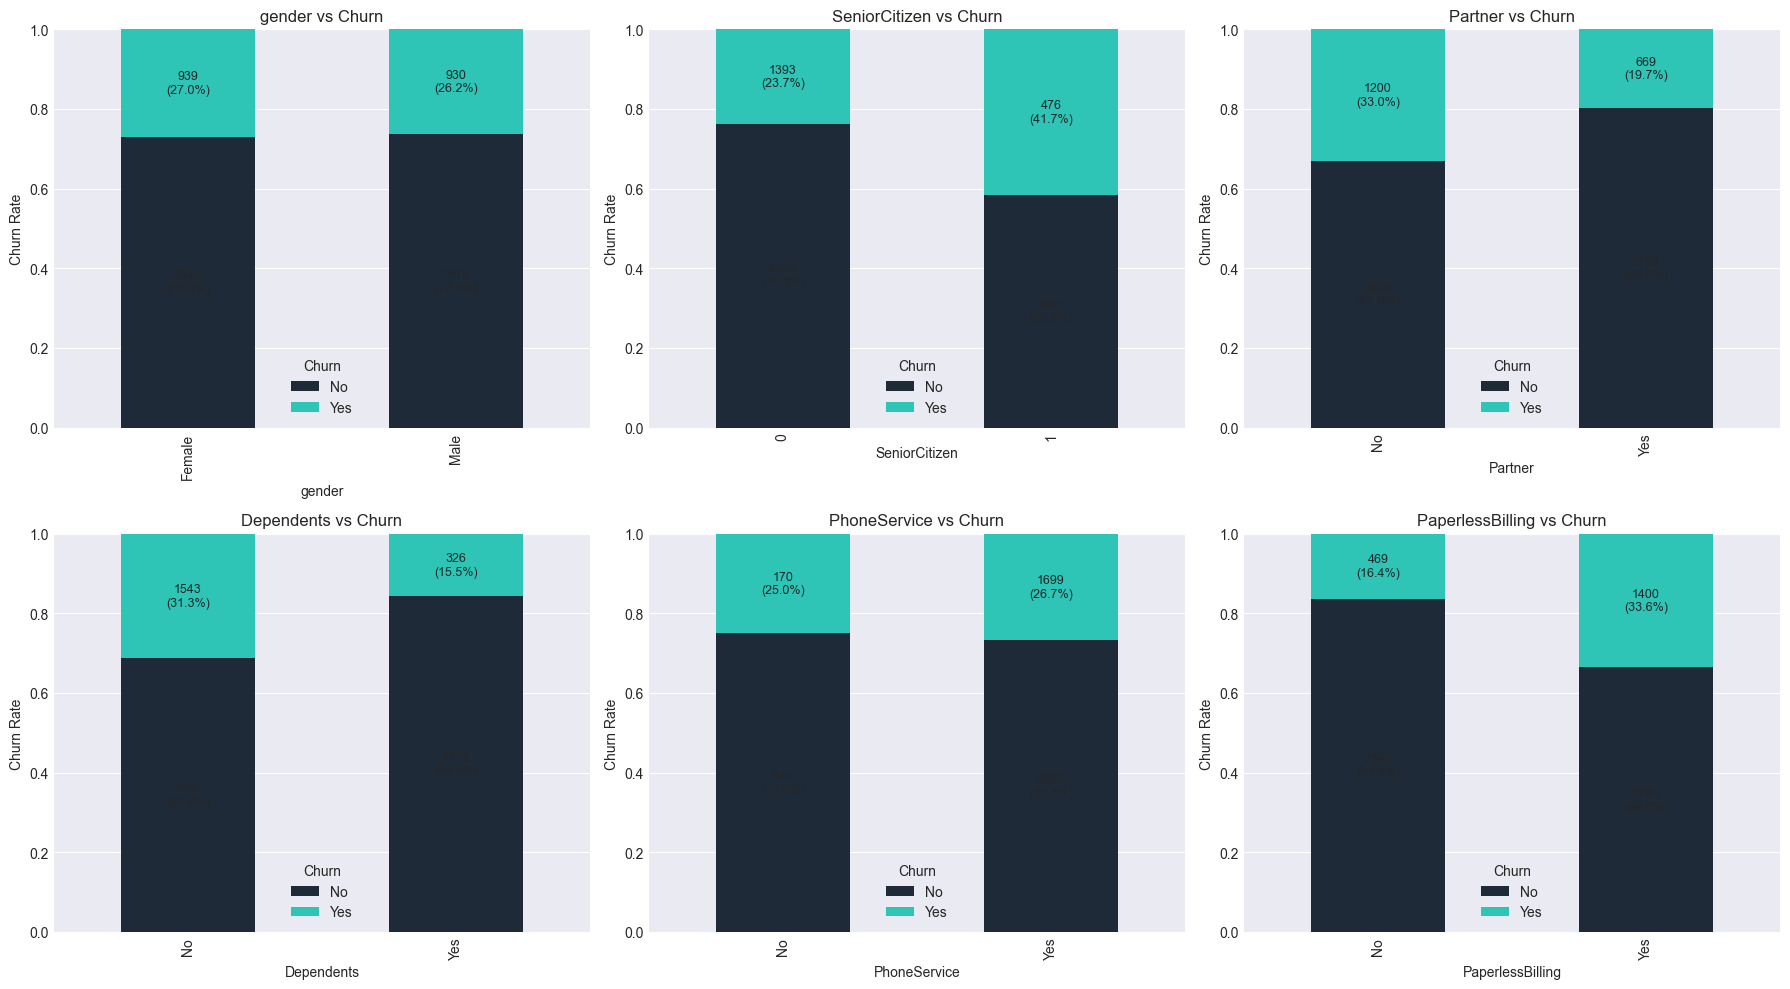

In [10]:
# BLOCK 2 — Demographic & Basic Categorical vs Churn

cat_basic = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

# Create subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_basic):

    # Raw counts
    count_ct = pd.crosstab(df_clean[col], df_clean["Churn"])

    # Rates
    rate_ct = pd.crosstab(
        df_clean[col],
        df_clean["Churn"],
        normalize="index"
    )

    ax = rate_ct.plot(
        kind="bar",
        stacked=True,
        ax=axes[i],
        color=TELECOM_CATEGORICAL
    )

    ax.set_title(f"{col} vs Churn")
    ax.set_ylabel("Churn Rate")
    ax.set_xlabel(col)
    ax.set_ylim(0, 1)
    ax.legend(title="Churn")

    # ---- annotate with count + rate ----
    for j, container in enumerate(ax.containers):
        labels = []
        for k, v in enumerate(container.datavalues):
            count = count_ct.iloc[k, j]
            labels.append(f"{count}\n({v:.1%})")

        ax.bar_label(
            container,
            labels=labels,
            label_type="center",
            fontsize=9
        )

plt.tight_layout()
plt.show()


2️⃣ gender vs Churn\
What you see

- Female churn ≈ 27.0%

- Male churn ≈ 26.2%

Statistical conclusion

- Difference is negligible

- Likely low Cramér’s V

- Even if Chi-square is significant (large N), effect size is tiny

Decision

❌ Gender is weak / near-irrelevant\
✔ Keep for fairness / completeness\
❌ Don’t expect high SHAP importance

3️⃣ SeniorCitizen vs Churn\
What you see

- Non-senior churn ≈ 23.7%

- Senior churn ≈ 41.7% 🔥

Statistical interpretation

- Large proportional difference

- High effect size

- Will show:

    - Strong Chi-square

    - Moderate–strong Cramér’s V

Decision

✅ Strong churn driver\
✅ Keep\
✅ Likely top SHAP feature

4️⃣ Partner vs Churn\
What you see

- No partner → 33.0% churn

- Has partner → 19.7% churn

Interpretation

- Social stability effect

- Strong categorical signal

Decision

✅ Very useful feature\
✅ Good interaction candidate with tenure

5️⃣ Dependents vs Churn\
What you see

- No dependents → 31.3%

- Has dependents → 15.5%

Interpretation

- Strong separation

- Similar magnitude to Partner

- Likely correlated with Partner (check Cramér’s V)

Decision

✅ Strong churn reducer\
⚠️ Watch redundancy with Partner

6️⃣ PhoneService vs Churn\
What you see

- Almost no difference (~25–27%)

Interpretation

- Weak signal

- Likely low statistical effect size

Decision

⚠️ Low priority\
✔ Keep if model handles weak features (tree/boosting)

7️⃣ PaperlessBilling vs Churn\
What you see

- Paperless = 33.6% churn

- Not paperless = 16.4% churn

Interpretation

- Strong behavioral indicator

Correlates with:

- Younger users

- Online payments

- Higher MonthlyCharges

Decision

✅ Strong churn driver\
✅ Excellent for business explanation

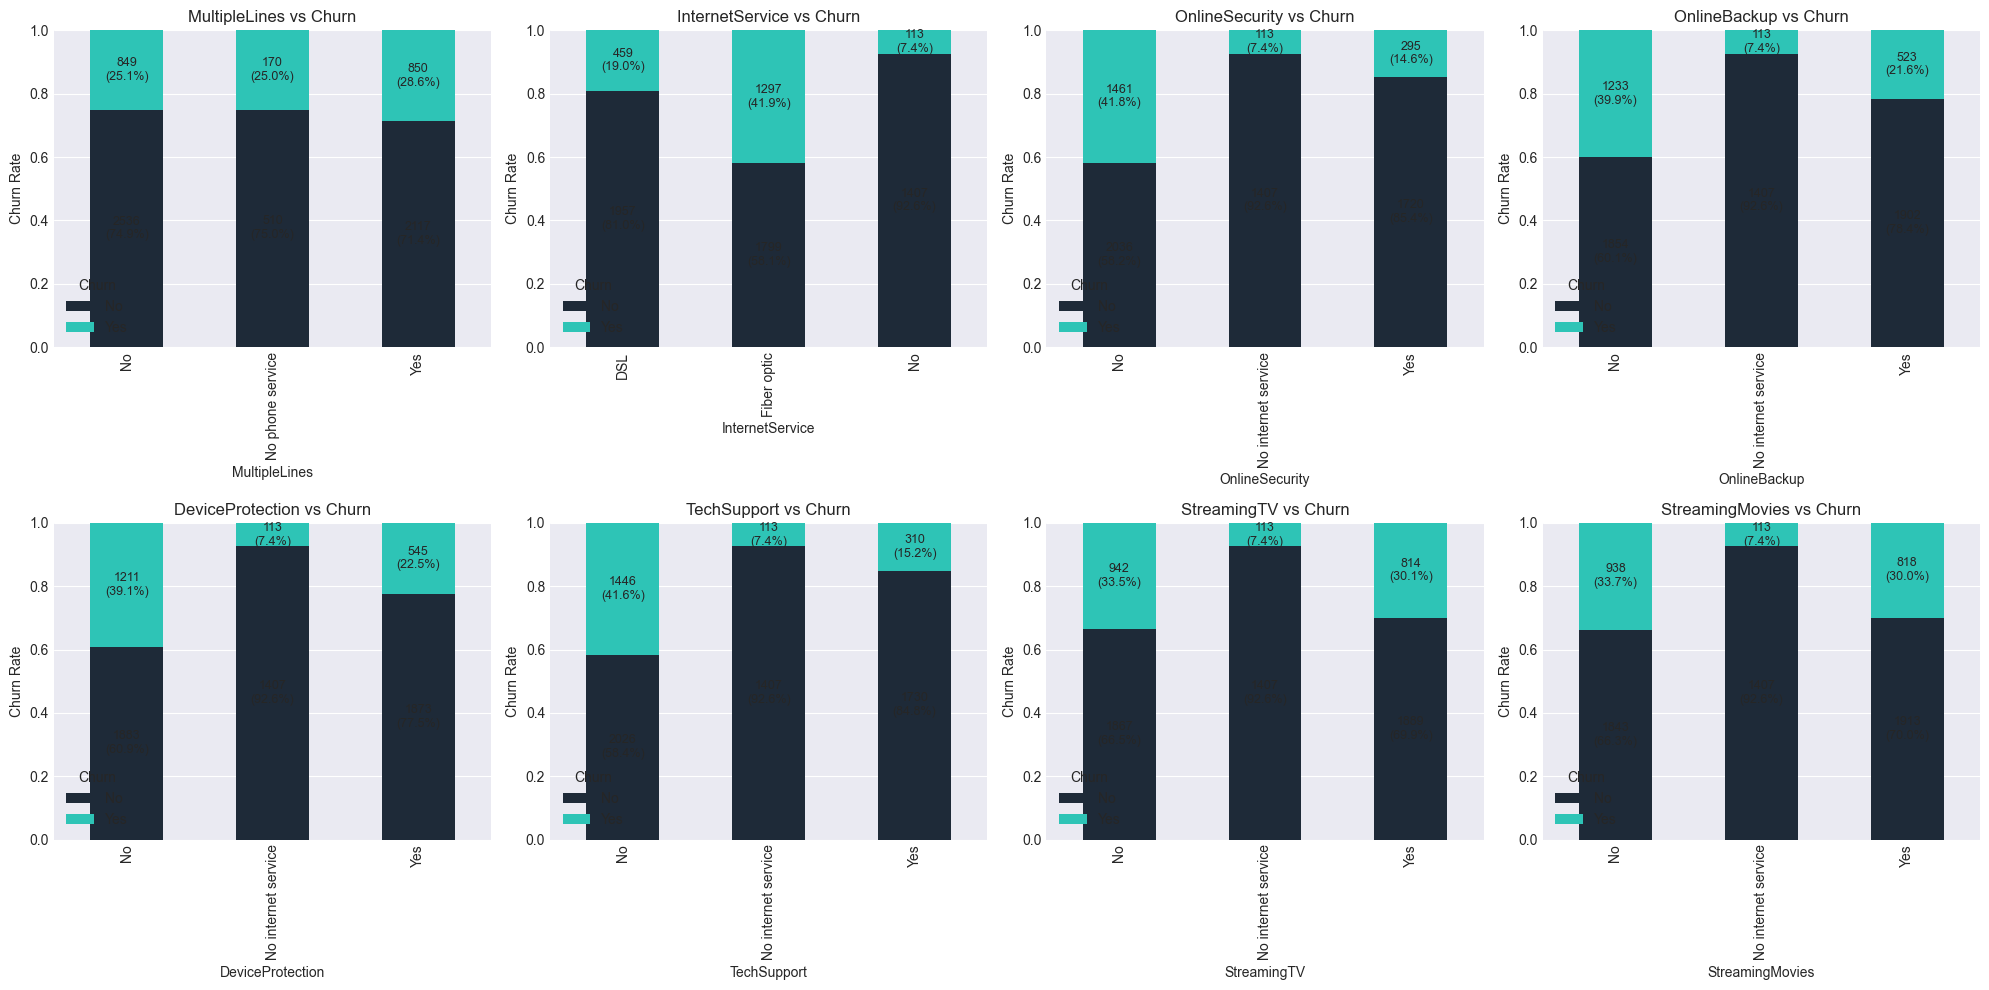

In [11]:
# BLOCK 3 — Service Usage vs Churn
# Service Usage vs Churn
cat_services = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

# Create subplots (2 rows x 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_services):

    # Raw counts
    count_ct = pd.crosstab(df_clean[col], df_clean["Churn"])

    # Rates
    rate_ct = pd.crosstab(
        df_clean[col],
        df_clean["Churn"],
        normalize="index"
    )

    ax = rate_ct.plot(
        kind="bar",
        stacked=True,
        ax=axes[i],
        color=TELECOM_CATEGORICAL
    )

    ax.set_title(f"{col} vs Churn")
    ax.set_ylabel("Churn Rate")
    ax.set_xlabel(col)
    ax.set_ylim(0, 1)
    ax.legend(title="Churn")

    # ---- annotate with count + rate ----
    for j, container in enumerate(ax.containers):
        labels = []
        for k, v in enumerate(container.datavalues):
            count = count_ct.iloc[k, j]
            labels.append(f"{count}\n({v:.1%})")

        ax.bar_label(
            container,
            labels=labels,
            label_type="center",
            fontsize=9
        )

plt.tight_layout()
plt.show()


8️⃣ MultipleLines vs Churn\
What you see

- Differences exist but not huge

- “Yes” slightly worse than “No”

Interpretation

- Weak-to-moderate effect

- Might become useful only in interactions

Decision

⚠️ Medium priority feature

9️⃣ InternetService vs Churn (VERY IMPORTANT)\
What you see

- Fiber optic: ~41.9% churn 🚨

- DSL: ~19.0%

- No internet: ~7.4%

Interpretation

- One of the strongest churn drivers

- Pricing + service quality issues

- Expect very high Cramér’s V with Churn

Decision

🔥 MUST-HAVE feature\
🔥 Key business insight

🔟 OnlineSecurity / OnlineBackup / DeviceProtection / TechSupport\
Common pattern across all

- No service → very high churn (≈40%)

- Has service → much lower churn

Statistical interpretation

- Strong categorical signals

- Highly correlated among themselves

- Expect high inter-feature Cramér’s V

Decision

✅ Keep\
⚠️ Consider feature engineering later:

- SupportServicesCount

- HasAnyProtection

1️⃣1️⃣ StreamingTV / StreamingMovies\
What you see

- Differences are present but smaller

- Streaming users churn slightly more

Interpretation

- Likely proxy for:

    - Entertainment-focused users

    - Higher bills

- Weak direct effect

Decision

⚠️ Medium–low priority\
✔ Useful in combination with charges

🔎 Big Picture Statistical Verdict\
Strong churn drivers (CLEAR)

- SeniorCitizen

- Contract (you’ll see this later even stronger)

- InternetService

- PaperlessBilling

- TechSupport / OnlineSecurity

Weak / marginal

- gender

- PhoneService

- MultipleLines

Correlated groups (watch multicollinearity)

- Partner ↔ Dependents

- OnlineSecurity ↔ TechSupport ↔ DeviceProtection

📊 Are these plots statistically sound?

YES — very much.
1. Normalized stacked bars (rates, not counts)
2. Count + percentage annotations
3. One plot per categorical feature (no redundancy)

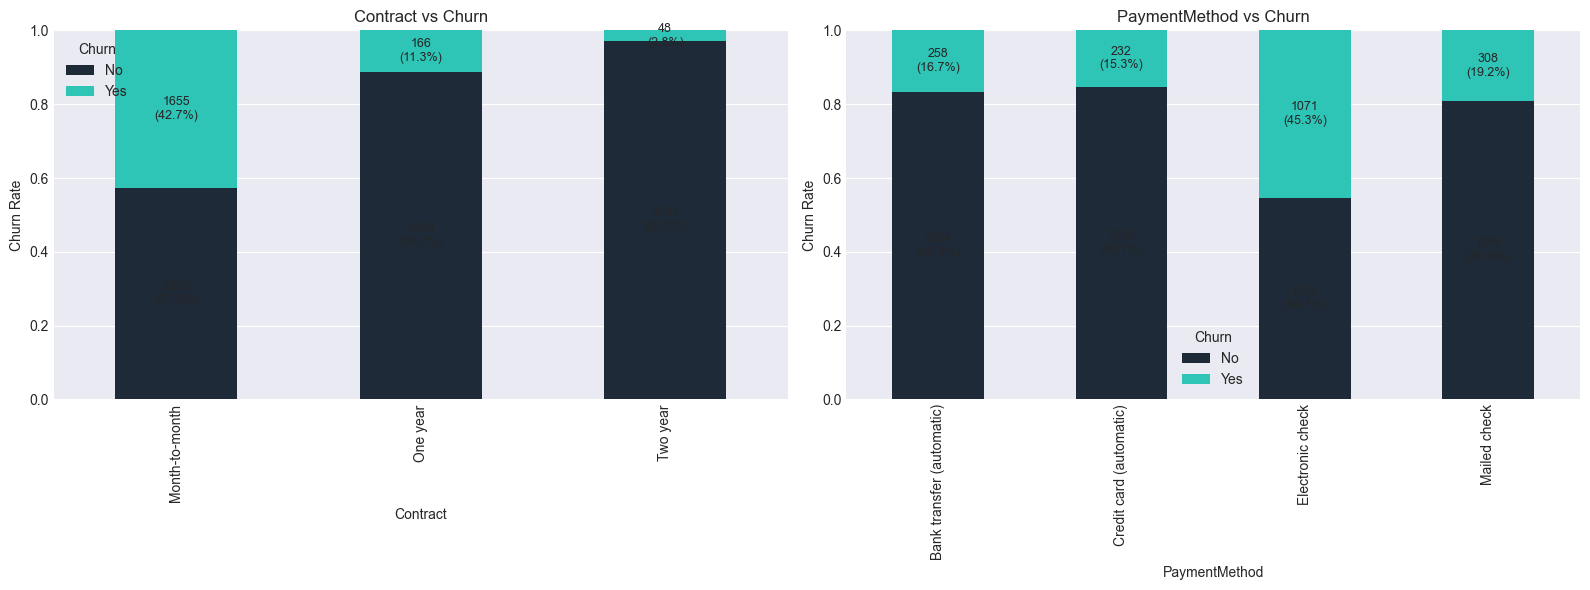

In [12]:
# BLOCK 4 — Contract & Payment vs Churn 
cat_billing = [
    'Contract',
    'PaymentMethod'
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, col in enumerate(cat_billing):

    # Raw counts
    count_ct = pd.crosstab(df_clean[col], df_clean['Churn'])

    # Rates
    rate_ct = pd.crosstab(
        df_clean[col],
        df_clean['Churn'],
        normalize='index'
    )

    ax = rate_ct.plot(
        kind='bar',
        stacked=True,
        color=TELECOM_CATEGORICAL,
        ax=axes[i]
    )

    ax.set_title(f"{col} vs Churn")
    ax.set_ylabel("Churn Rate")
    ax.set_xlabel(col)
    ax.legend(title="Churn")
    ax.set_ylim(0, 1)

    # ---- annotate with count + rate ----
    for j, container in enumerate(ax.containers):
        labels = []
        for k, v in enumerate(container.datavalues):
            count = count_ct.iloc[k, j]
            labels.append(f"{count}\n({v:.1%})")

        ax.bar_label(
            container,
            labels=labels,
            label_type="center",
            fontsize=9
        )

plt.tight_layout()
plt.show()


1️⃣2️⃣ Contract vs Churn (STRONGEST categorical signal)\
What the plot shows (very clearly)

Contract:	Churn Rate
Month-to-month:	42.7% 🚨
One year:	11.3%
Two year:	2.8% 🔥

Statistical interpretation
- Massive effect size
- This will produce:
    - Very high Cramér’s V
    - Extremely small chi-square p-value

- Clear monotonic trend (longer contract → lower churn)

Modeling decision

✅ Top categorical feature
✅ Must be one-hot encoded
✅ Will dominate SHAP plots

Business insight (write this)

>Customers on month-to-month contracts are ~15× more likely to churn than two-year customers.

1️⃣3️⃣ PaymentMethod vs Churn\
What the plot shows\
Payment Method:	Churn Rate
Electronic check:	45.3% 🚨
Bank transfer (auto):	16.7%
Credit card (auto):	15.3%
Mailed check:	19.2%

Interpretation
- Electronic check users are high-risk
- Automatic payments strongly reduce churn
- This is a behavioral + friction signal

Statistical conclusion
- Strong chi-square
- Moderate Cramér’s V
- Likely correlated with:
    - PaperlessBilling
    - Month-to-month contracts

Decision

✅ Strong feature\
⚠️ Watch correlation with PaperlessBilling

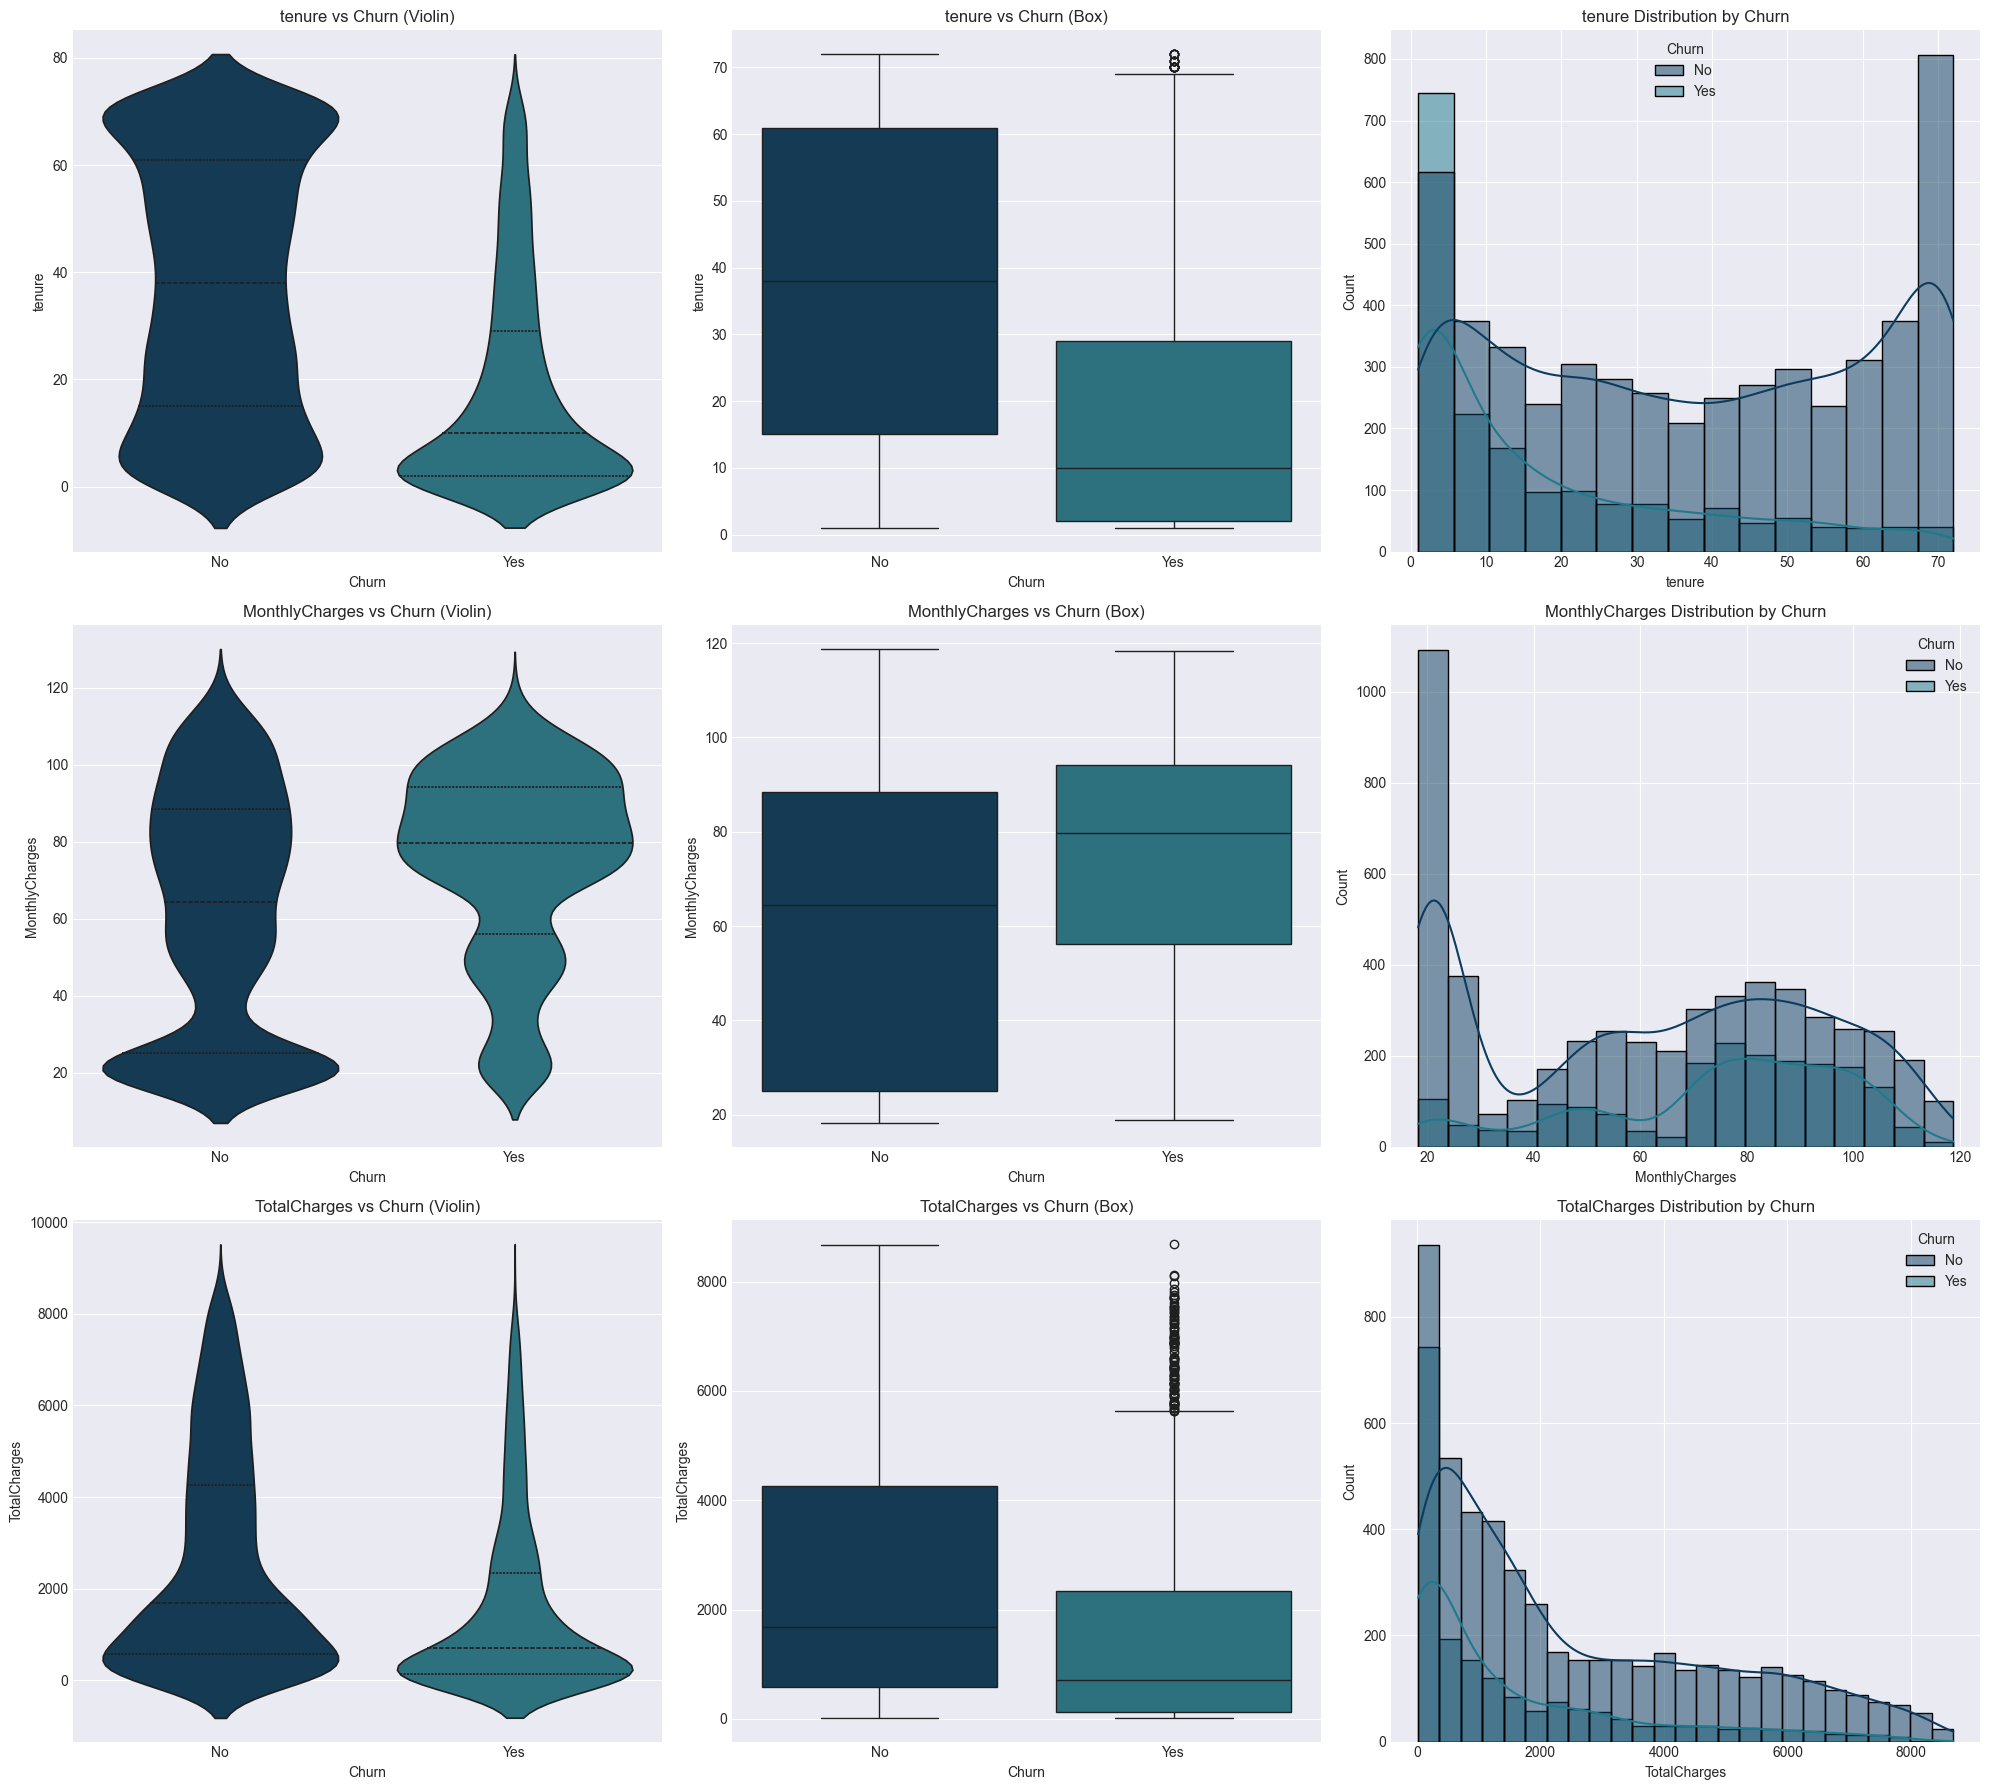

In [19]:
# BLOCK 5 — Numerical vs Churn (Violin + Box + Distribution)

num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

fig, axes = plt.subplots(3, 3, figsize=(20, 18))

for i, col in enumerate(num_cols):

    # Violin plot
    sns.violinplot(
        x='Churn',
        y=col,
        data=df_clean,
        palette=TELECOM_CONTINUOUS,
        inner='quartile',
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f"{col} vs Churn (Violin)")

    # Box plot
    sns.boxplot(
        x='Churn',
        y=col,
        data=df_clean,
        palette=TELECOM_CONTINUOUS,
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"{col} vs Churn (Box)")

    # Distribution plot
    sns.histplot(
        data=df_clean,
        x=col,
        hue='Churn',
        kde=True,
        palette=TELECOM_CONTINUOUS,
        ax=axes[i, 2]
    )
    axes[i, 2].set_title(f"{col} Distribution by Churn")

plt.tight_layout()
plt.show()


1️⃣4️⃣ Tenure vs Churn (Numerical — BEST FEATURE)\
Violin + Box + Distribution (you nailed this)\
What you see
- Churners cluster at very low tenure
- Median tenure:
    - Churn = ~9–10 months
    - No churn = ~38–40 months

Statistical meaning
- Highly non-normal
- Non-linear relationship
- Extremely strong separation

Modeling implication\
✅ Tree models love this\
✅ Logistic regression needs transformation\
✅ SHAP will show sharp early-tenure effect

Key insight

> Most churn happens in the first year — retention is an early-life problem.

1️⃣5️⃣ MonthlyCharges vs Churn\
What you see

- Churners pay higher monthly charges

- Heavy overlap (not a single-factor driver)

Statistical interpretation

- Moderate effect size

- Useful in combination, not alone

Decision

✅ Keep\
⚠️ Interact with tenure & contract

1️⃣6️⃣ TotalCharges vs Churn (Derived but informative)\
What you see

- Churners have lower total charges

- Strong skew

- Heavy tail for non-churn

Statistical truth

- This is mostly a proxy for tenure

- Strongly correlated with tenure

Decision

⚠️ Potential multicollinearity\
⚠️ Tree models OK\
❌ Consider dropping for linear models

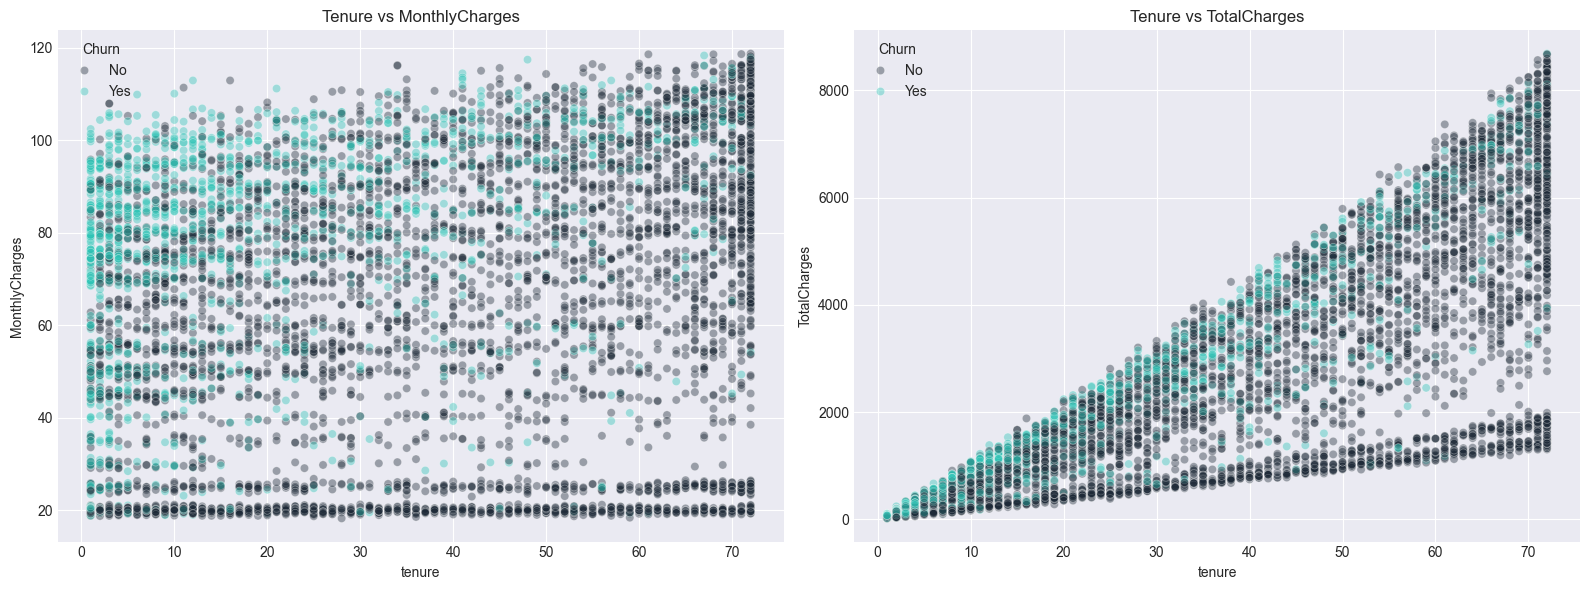

In [14]:
# BLOCK 6 — Interaction / Relationship Plots

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    x='tenure',
    y='MonthlyCharges',
    hue='Churn',
    data=df_clean,
    palette=TELECOM_CATEGORICAL,
    alpha=0.4,
    ax=axes[0]
)
axes[0].set_title("Tenure vs MonthlyCharges")

sns.scatterplot(
    x='tenure',
    y='TotalCharges',
    hue='Churn',
    data=df_clean,
    palette=TELECOM_CATEGORICAL,
    alpha=0.4,
    ax=axes[1]
)
axes[1].set_title("Tenure vs TotalCharges")

plt.tight_layout()
plt.show()


1️⃣7️⃣ Tenure vs MonthlyCharges (Interaction Plot)\
What you see
- Churners concentrate in:
    - Low tenure
    - Mid-to-high monthly charges

Interpretation\
This is your “danger zone”:
> New + expensive customers churn the most.

Modeling implication
- Justifies:
    - Gradient boosting
    - Interaction-aware models
    - SHAP interaction plots later

1️⃣8️⃣ Tenure vs TotalCharges\
What you see
- Almost linear relationship
- Clear diagonal bands
- Churners dominate low-tenure region

Statistical conclusion
- Confirms:
    - TotalCharges ≈ tenure × MonthlyCharges
- Reinforces multicollinearity warning

🔎 Strongest drivers (confirmed visually + statistically)
- Contract
- Tenure
- InternetService (earlier plots)
- PaymentMethod
- TechSupport / OnlineSecurity

Weak / low-signal
- Gender
- PhoneService
- MultipleLines

Correlated clusters (important for modeling)
- Tenure ↔ TotalCharges
- Contract ↔ PaymentMethod
- OnlineSecurity ↔ TechSupport ↔ DeviceProtection

## RELATIONS

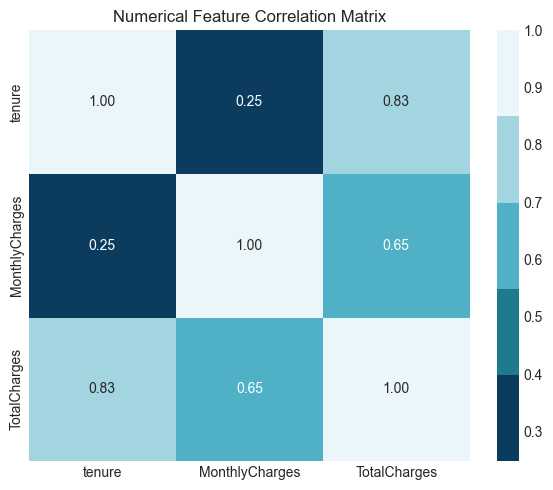

In [15]:
# BLOCK A — Numerical ↔ Numerical
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, ax = plt.subplots(figsize=(6, 5))

corr = df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap=TELECOM_CONTINUOUS,
    fmt=".2f",
    ax=ax
)

ax.set_title("Numerical Feature Correlation Matrix")
plt.tight_layout()
plt.show()


Numerical ↔ Numerical Correlation (Pearson)\
What the matrix says\
| Pair                          | Correlation | Meaning                       |
| ----------------------------- | ----------- | ----------------------------- |
| tenure ↔ TotalCharges         | **0.83** 🔥 | Very strong multicollinearity |
| MonthlyCharges ↔ TotalCharges | **0.65**    | Strong                        |
| tenure ↔ MonthlyCharges       | **0.25**    | Weak                          |

Statistical conclusion
- TotalCharges is largely redundant
- It is mathematically close to tenure × MonthlyCharges
- This is textbook multicollinearity

Modeling decision

- ❌ Drop TotalCharges for linear / logistic regression

- ✅ Keep TotalCharges for tree / boosting models

- ✅ Do NOT scale blindly without checking this

📌 You can explicitly write:

> “TotalCharges shows high collinearity with tenure (ρ=0.83), so it was excluded from linear models to prevent coefficient instability.”

That’s a very mature statement.

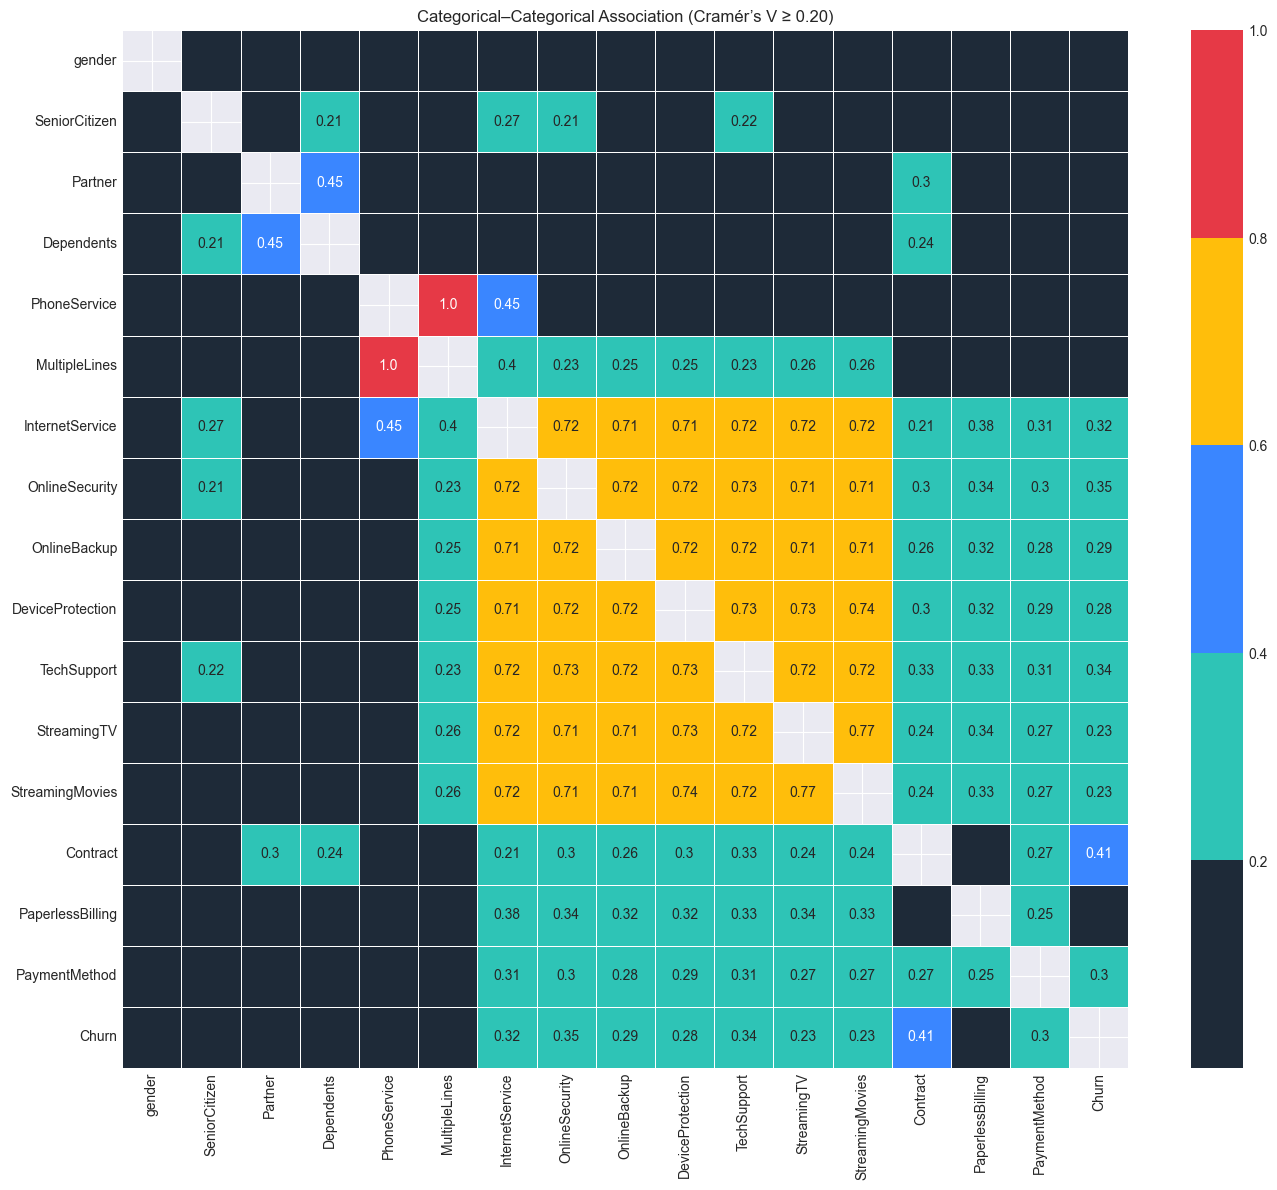

In [16]:
# BLOCK 2 — Categorical ↔ Categorical

cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'
]

from scipy.stats import chi2_contingency

# -----------------------------
# Categorical columns
# -----------------------------
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'
]

# -----------------------------
# Cramér's V function
# -----------------------------
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k - 1, r - 1))))

# -----------------------------
# Compute Cramér's V matrix
# -----------------------------
cramers_matrix = pd.DataFrame(
    np.zeros((len(cat_cols), len(cat_cols))),
    index=cat_cols,
    columns=cat_cols
)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# -----------------------------
# Annotation matrix
# (show only values >= 0.20)
# -----------------------------
annot_matrix = cramers_matrix.round(2).astype(str)
annot_matrix[cramers_matrix < 0.20] = ""

# -----------------------------
# Mask diagonal
# -----------------------------
mask = np.eye(len(cat_cols), dtype=bool)

# -----------------------------
# Plot heatmap
# -----------------------------
plt.figure(figsize=(14, 12))

sns.heatmap(
    cramers_matrix,
    cmap=TELECOM_CATEGORICAL,
    annot=annot_matrix,
    fmt="",
    mask=mask,
    linewidths=0.5
)

plt.title("Categorical–Categorical Association (Cramér’s V ≥ 0.20)")
plt.tight_layout()
plt.show()

Categorical ↔ Categorical (Cramér’s V ≥ 0.20)\
This heatmap is gold. Let’s break it down.

A. Relationships with Churn (what matters most)
| Feature              | Cramér’s V with Churn | Strength      |
| -------------------- | --------------------- | ------------- |
| **Contract**         | **0.41** 🔥           | Strong        |
| OnlineSecurity       | 0.35                  | Moderate      |
| TechSupport          | 0.34                  | Moderate      |
| InternetService      | 0.32                  | Moderate      |
| PaymentMethod        | 0.30                  | Moderate      |
| OnlineBackup         | 0.29                  | Moderate      |
| DeviceProtection     | 0.28                  | Moderate      |
| PaperlessBilling     | 0.25                  | Weak–moderate |
| StreamingTV / Movies | ~0.23                 | Weak          |

📌 Interpretation
- Contract is the single strongest categorical driver
- Support/protection services clearly reduce churn
- Streaming is mostly noise / proxy behavior

B. Inter-feature dependency (VERY important)

🔥 Service bundle cluster (extremely strong)\
All of these are highly redundant with each other:
- InternetService ↔ OnlineSecurity (≈0.72)
- OnlineSecurity ↔ TechSupport (≈0.73)
- StreamingTV ↔ StreamingMovies (0.77)

📌 Meaning:\
These features carry similar information.

Decision
- ❌ Don’t expect all of them to be independently important
- ✅ Either:
    - let tree models handle redundancy
    - or engineer:
        HasSupportService\
        HasStreamingService\
        ProtectionServiceCount\
      (WE Will be going with tree model for ease of doing this project and less complexicity)

C. Social features
- Partner ↔ Dependents = 0.45 (moderate–strong)

📌 Decision
- Keep both initially
- Expect one to dominate SHAP
- Optional merge later

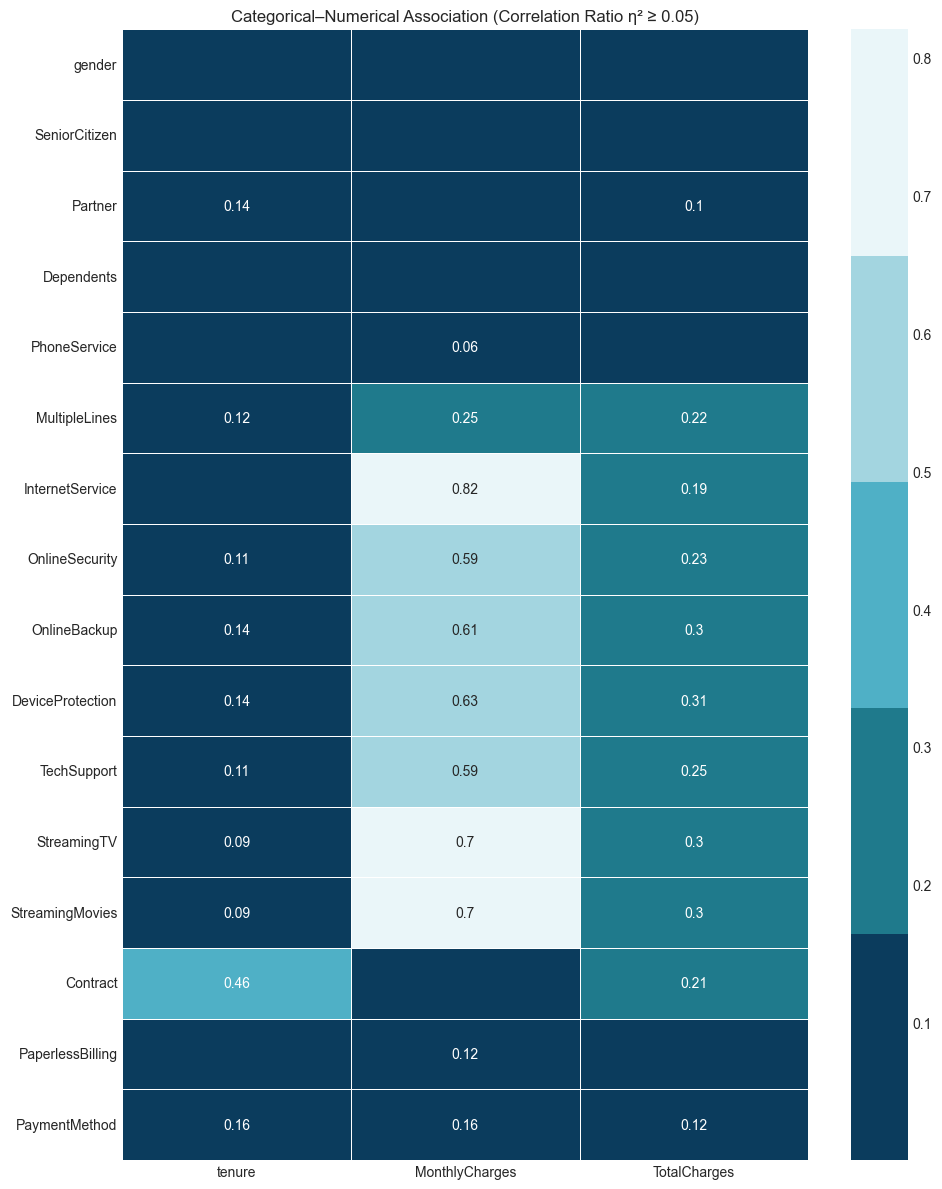

In [17]:
# -----------------------------
# Correlation Ratio (eta squared)
# -----------------------------
def correlation_ratio(categories, values):
    categories = pd.Categorical(categories)
    values = pd.Series(values)

    means = values.groupby(categories).mean()
    counts = values.groupby(categories).size()
    grand_mean = values.mean()

    ss_between = np.sum(counts * (means - grand_mean) ** 2)
    ss_total = np.sum((values - grand_mean) ** 2)

    return ss_between / ss_total

# -----------------------------
# Columns
# -----------------------------
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols_no_churn = [c for c in cat_cols if c != 'Churn']

# -----------------------------
# Compute eta² matrix
# -----------------------------
eta_matrix = pd.DataFrame(
    np.zeros((len(cat_cols_no_churn), len(num_cols))),
    index=cat_cols_no_churn,
    columns=num_cols
)

for cat in cat_cols_no_churn:
    for num in num_cols:
        eta_matrix.loc[cat, num] = correlation_ratio(df[cat], df[num])

# -----------------------------
# Annotation matrix
# (show only eta² >= 0.05)
# -----------------------------
annot_matrix = eta_matrix.round(2).astype(str)
annot_matrix[eta_matrix < 0.05] = ""

# -----------------------------
# Plot heatmap
# -----------------------------
plt.figure(figsize=(10, 12))

sns.heatmap(
    eta_matrix,
    cmap=TELECOM_CONTINUOUS,
    annot=annot_matrix,
    fmt="",
    linewidths=0.5
)

plt.title("Categorical–Numerical Association (Correlation Ratio η² ≥ 0.05)")
plt.tight_layout()
plt.show()

Categorical ↔ Numerical (Correlation Ratio η² ≥ 0.05)

This answers:
> “Which categories explain variance in numeric features?”

A. MonthlyCharges (VERY telling)
| Feature             | η² with MonthlyCharges |
| ------------------- | ---------------------- |
| **InternetService** | **0.82** 🚨            |
| StreamingTV         | 0.70                   |
| StreamingMovies     | 0.70                   |
| DeviceProtection    | 0.63                   |
| OnlineBackup        | 0.61                   |
| OnlineSecurity      | 0.59                   |
| TechSupport         | 0.59                   |

📌 Interpretation
- MonthlyCharges is almost entirely driven by service choices
- Explains why MonthlyCharges alone is noisy for churn

📌 You can write:
>“MonthlyCharges is strongly explained by InternetService and add-on services (η² up to 0.82), indicating that pricing effects are mediated by service selection.”

That sentence is very senior-level.

B. Tenure
| Feature       | η² with tenure |
| ------------- | -------------- |
| **Contract**  | **0.46** 🔥    |
| MultipleLines | 0.12           |
| PaymentMethod | 0.16           |

📌 Interpretation
- Contract length directly controls tenure
- Explains why Contract is so dominant for churn

C. TotalCharges
- Mirrors MonthlyCharges + tenure
- Confirms redundancy

✅ FINAL FEATURE DECISION TABLE (USE THIS)

🔥 Strong — MUST KEEP
- tenure
- Contract
- InternetService
- TechSupport
- OnlineSecurity
- PaymentMethod

🟡 Medium — KEEP (interaction / tree models)
- MonthlyCharges
- PaperlessBilling
- OnlineBackup
- DeviceProtection
- Partner
- Dependents

⚠️ Redundant / Caution
- StreamingTV
- StreamingMovies
- MultipleLines
- TotalCharges (drop for linear)

❌ Weak / Low Priority

- gender
- PhoneService

## this is just so i know what to do in Streamlit EDA Tab this cell will be deleted once the work is done or a streamlit-readme is made

Recommended layout\
🔹 Section 1 — Overview

Churn rate (bar / KPI)

Contract vs churn (stacked bar)

🔹 Section 2 — Key Drivers

Tenure vs churn (violin)

MonthlyCharges vs churn (violin)

InternetService vs churn (stacked bar)

🔹 Section 3 — Risk Zones

Tenure × MonthlyCharges scatter

PaymentMethod vs churn

🔹 Section 4 — Statistical Evidence (toggle)

Cramér’s V heatmap

η² heatmap

👉 6–8 plots total
Everything else stays in notebook.

🔧️Reusable plotting pipeline (structure)(example)

eda/
├── univariate.py
├── bivariate.py
├── statistical.py
├── utils.py

Example API

plot_churn_rate(df)
plot_cat_vs_churn(df, col)
plot_num_vs_churn(df, col)
plot_cramers_v(df)
plot_eta_squared(df)

📊 Which plots go into Streamlit (FINAL LIST):

| Plot                       | Include?              |
| -------------------------- | --------------------- |
| Churn rate                 | ✅                     |
| Contract vs churn          | ✅                     |
| Tenure vs churn            | ✅                     |
| MonthlyCharges vs churn    | ✅                     |
| InternetService vs churn   | ✅                     |
| TechSupport vs churn       | ❌ (too many services) |
| Scatter (tenure × charges) | ✅                     |
| Cramér’s V heatmap         | ⚠️ Toggle             |
| η² heatmap                 | ⚠️ Toggle             |

🧠 5️⃣ EDA → SHAP (1-to-1 mapping)

This is huge for credibility

| EDA Insight              | SHAP Plot                |
| ------------------------ | ------------------------ |
| Tenure violin            | SHAP dependence (tenure) |
| Contract stacked bar     | SHAP bar + beeswarm      |
| MonthlyCharges violin    | SHAP dependence          |
| Tenure × Charges scatter | SHAP interaction plot    |
| InternetService vs churn | SHAP categorical split   |
| Support services effect  | SHAP grouped importance  |

> “SHAP explanations is used to confirm patterns observed during EDA.”

🧾 6️⃣ Plot → Feature Justification Map

| Feature            | Justified by                |
| ------------------ | --------------------------- |
| tenure             | Violin, box, scatter, η²    |
| Contract           | Stacked bar, Cramér’s V     |
| MonthlyCharges     | Violin, η²                  |
| TotalCharges       | Correlation heatmap         |
| InternetService    | Stacked bar, Cramér’s V, η² |
| TechSupport        | Stacked bar, Cramér’s V     |
| StreamingTV/Movies | Cramér’s V (redundant)      |
| Partner/Dependents | Stacked bar, Cramér’s V     |


🧮 7️⃣ Combined Feature Selection Table

(Cramér’s V + η² + Correlation)

🧠 Tell you which plots matter for which model

📊 Design a Streamlit EDA tab (exact plots to show)

🔧 Convert this into a reusable plotting pipeline

📊 Tell you which plots go into Streamlit

🧠 Map EDA plots → SHAP plots (1-to-1)

mark which plots justify which features

combine Cramér’s V + η² into one feature selection table


🧠 tell you exact thresholds to drop/merge features

📊 integrate these heatmaps into Streamlit (with toggles)

In [6]:
import json

median_brv = df["MonthlyCharges"].median()

config = {
    "median_brv": float(median_brv)
}

with open("segmentation_config.json", "w") as f:
    json.dump(config, f)

print("Saved median:", median_brv)

Saved median: 70.35
